<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/hinge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D
from keras.layers import Add, Input
from keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


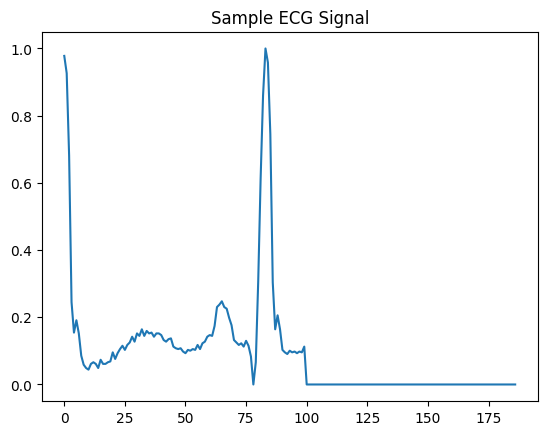

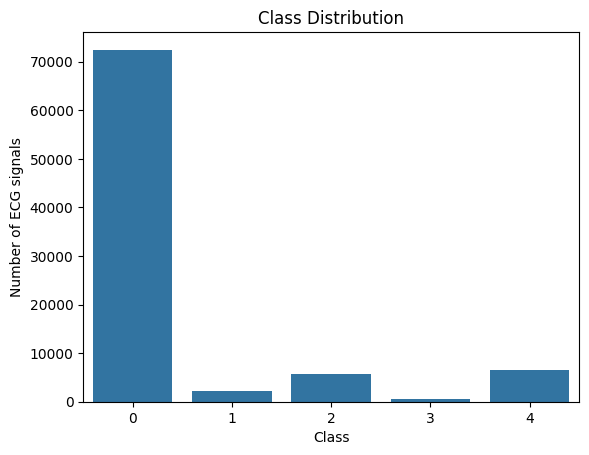

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [7]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [19]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# Convert labels from {0,1} → {-1,1}
y_res_cat = (y_res_cat * 2) - 1
y_test_cat = (y_test_cat * 2) - 1

X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [20]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x


def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)
    x = Dense(5,activation='tanh')(x)   # 🔥 SAME AS YOUR HINGE SETUP

    model = Model(inputs,x)

    model.compile(
        optimizer='adam',
        loss='hinge',
        metrics=['accuracy']
    )

    return model

In [21]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - accuracy: 0.6514 - loss: 0.2088
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.7242 - loss: 0.1913
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.7383 - loss: 0.1865
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.7446 - loss: 0.1839
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.7496 - loss: 0.1815

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.3713 - loss: 0.3616
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.5582 - loss: 0.2584
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.5711 - loss: 0.2538
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.5760 - loss: 0.2521
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.5795 - loss: 0.2503

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.8230 - loss: 0.1359
Epoch

In [23]:
model = resnet_ecg()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=64
)



Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step - accuracy: 0.4890 - loss: 0.2800 - val_accuracy: 0.5183 - val_loss: 0.2687
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 69s 10ms/step - accuracy: 0.5300 - loss: 0.2691 - val_accuracy: 0.5389 - val_loss: 0.2671
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.5386 - loss: 0.2666 - val_accuracy: 0.5283 - val_loss: 0.2757
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.5447 - loss: 0.2643 - val_accuracy: 0.5383 - val_loss: 0.2664
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.5488 - loss: 0.2629 - val_accuracy: 0.5557 - val_loss: 0.2609
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.5532 - loss: 0.2607 - val_accuracy: 0.3710 - val_loss: 0.3410
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.5563 - loss: 0.2596 - val_accuracy: 0.5404 - val_loss: 0.2629
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.5571 -

In [24]:
# MCC
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax((y_val+1)/2, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc)



2265/2265 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step
Validation MCC: 0.5002922002967699


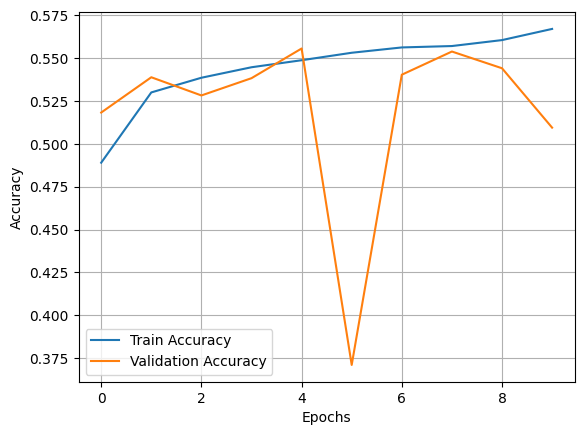

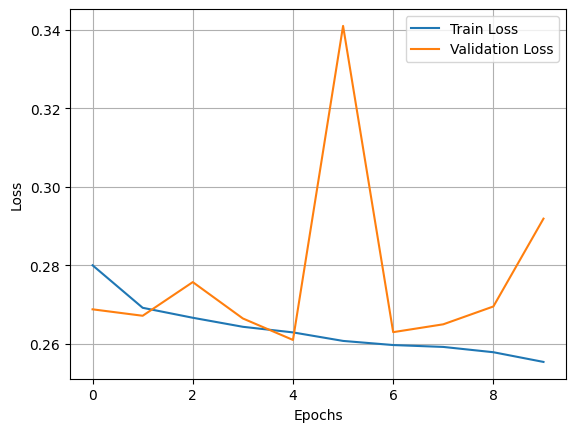

Final Training Accuracy: 0.5671
Final Validation Accuracy: 0.5095
Final Training Loss: 0.2553
Final Validation Loss: 0.2919


In [26]:
# Accuracy Graph
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Final values
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")



In [25]:
# Test
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))



Test Loss: 0.3963
Test Accuracy: 0.8383
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91     18118
         1.0       0.77      0.41      0.54       556
         2.0       0.00      0.00      0.00      1448
         3.0       0.67      0.70      0.68       162
         4.0       0.00      0.00      0.00      1608

    accuracy                           0.84     21892
   macro avg       0.46      0.42      0.43     21892
weighted avg       0.72      0.84      0.77     21892



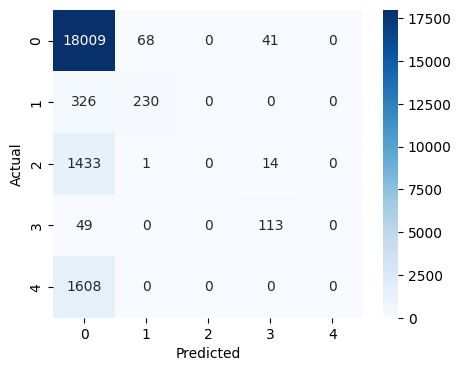

In [27]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()